# Numerical Heston - Initial exploration
**Goal.** Build the numerical (simulation-based) Heston pipeline in numpy, grounded in real market data.
The eventual target is a generative model over implied-volatility surfaces; this notebook builds the
foundations in order:

1. **Market IV surface** from the NSE F&O data - the object Heston is calibrated to (this notebook).
2. **Numerical Heston simulator** (full-truncation Euler Monte-Carlo) → model IV surface *(next cells)*.
3. **Calibration** of $(\kappa,\theta,\xi,\rho,v_0)$ to the market surface *(later)*.
4. **Synthetic surface dataset** by sampling parameters around the calibrated values - the flow-matching target *(later)*.

> The uploaded CSV is **real market option prices** (NSE F&O end-of-day bhavcopy), not Heston output.
> It plays the role of the *calibration target / reality anchor*, not the training data itself.

## 0. Data exploration

NSE F&O end-of-day bhavcopy. We profile it before using it: which instruments, date range, and how
liquid the NIFTY option chain actually is (this drives every downstream choice).

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

CSV = "data/3mfanddo.csv"   # adjust path if needed

cols = ["INSTRUMENT","SYMBOL","EXPIRY_DT","STRIKE_PR","OPTION_TYP","CLOSE","CONTRACTS","OPEN_INT","TIMESTAMP"]
df = pd.read_csv(CSV, usecols=cols)
print("rows:", len(df))
print("\ninstruments:\n", df.INSTRUMENT.value_counts())
df["TS"] = pd.to_datetime(df.TIMESTAMP, format="%d-%b-%Y", errors="coerce")
print("\ntrade dates:", df.TS.min().date(), "->", df.TS.max().date(), "|", df.TS.nunique(), "days")
print("\ntop symbols:\n", df.SYMBOL.value_counts().head(6))

rows: 2533210

instruments:
 INSTRUMENT
OPTSTK    2152486
OPTIDX     348752
FUTSTK      31351
FUTIDX        621
Name: count, dtype: int64

trade dates: 2019-08-01 -> 2019-11-15 | 69 days

top symbols:
 SYMBOL
NIFTY        229069
BANKNIFTY     83707
NIFTYIT       36597
COLPAL        20391
NBCC          19287
NCC           18587
Name: count, dtype: int64


In [3]:
# NIFTY index options are the clean instrument for Heston.
opt = df[(df.SYMBOL=="NIFTY") & (df.INSTRUMENT=="OPTIDX")].copy()
opt["EXP"] = pd.to_datetime(opt.EXPIRY_DT, format="%d-%b-%Y")
print("NIFTY OPTIDX rows:", len(opt))
print("strikes:", opt.STRIKE_PR.nunique(), "| range", opt.STRIKE_PR.min(), "-", opt.STRIKE_PR.max())
print("expiries:", opt.EXP.nunique())

# Liquidity reality-check on one date: most strikes never trade -> filtering is mandatory.
probe = opt[opt.TS == pd.Timestamp("2019-08-01")]
print("\nOn 2019-08-01: rows", len(probe),
      "| traded (CONTRACTS>0):", round((probe.CONTRACTS>0).mean(), 3),
      "| OI>0:", round((probe.OPEN_INT>0).mean(), 3))

NIFTY OPTIDX rows: 228862
strikes: 144 | range 4600.0 - 14500.0
expiries: 37

On 2019-08-01: rows 3334 | traded (CONTRACTS>0): 0.121 | OI>0: 0.234


## 1. Black-76 pricing and inversion

Options are quoted against the **forward** (from the futures / parity), so we use Black-76 (the forward
form of Black-Scholes) rather than spot Black-Scholes:

$$C = e^{-rT}\big(F\,N(d_1) - K\,N(d_2)\big),\quad
d_{1,2} = \frac{\ln(F/K) \pm \tfrac12\sigma^2 T}{\sigma\sqrt T}.$$

Implied vol is the $\sigma$ that reprices a quote; we solve it by Brent's method.

In [4]:
def black76(F, K, T, r, sigma, cp):
    """Black-76 price on a forward F. cp = 'C' or 'P'."""
    if sigma <= 0 or T <= 0:
        return max((F - K) if cp == "C" else (K - F), 0.0) * np.exp(-r * T)
    srt = sigma * np.sqrt(T)
    d1  = (np.log(F / K) + 0.5 * sigma * sigma * T) / srt
    d2  = d1 - srt
    D   = np.exp(-r * T)
    if cp == "C":
        return D * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return D * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def implied_vol(price, F, K, T, r, cp):
    """Invert Black-76 for sigma; NaN if price is below intrinsic (unrecoverable)."""
    intrinsic = np.exp(-r * T) * max((F - K) if cp == "C" else (K - F), 0.0)
    if price <= intrinsic + 1e-6:
        return np.nan
    try:
        return brentq(lambda s: black76(F, K, T, r, s, cp) - price, 1e-3, 5.0, maxiter=100)
    except ValueError:
        return np.nan

## 2. Forward from put-call parity

We do **not** assume a spot or dividend. Put-call parity $C-P = e^{-rT}(F-K)$ recovers the forward per
expiry directly from option prices: $F = K + (C-P)/e^{-rT}$, taken as the median over paired strikes.

> **On the rate.** Parity's *slope* also encodes $e^{-rT}$, but with thin liquidity at short $T$ that
> estimate is unstable (it implied 48–80% rates here). So we fix $r$ to a market value (RBI repo
> $\approx 5.4\%$ in Aug 2019) and use parity only for the forward. This is an assumption, flagged.

In [5]:
R = 0.054   # assumed risk-free rate (annual, continuous) -- see note above

def forward_from_parity(group, r, T):
    ce = group[group.OPTION_TYP == "CE"].set_index("STRIKE_PR").CLOSE
    pe = group[group.OPTION_TYP == "PE"].set_index("STRIKE_PR").CLOSE
    k  = ce.index.intersection(pe.index).values.astype(float)
    if len(k) < 3:
        return np.nan
    diff = ce.reindex(k).values - pe.reindex(k).values
    return float(np.median(k + diff / np.exp(-r * T)))

## 3. Build the market IV surface

For a chosen trade date: keep liquid rows (`CONTRACTS > 0`), recover $F(T)$ per expiry, and invert
Black-76 on the **out-of-the-money wing** (calls above the forward, puts below) - the numerically
stable side. Output is a tidy table `(TTM, K, forward, log-moneyness, iv, cp)`.

In [6]:
TRADE_DATE = pd.Timestamp("2019-08-01")

def build_surface(opt, trade_date, r):
    day = opt[(opt.TS == trade_date) & (opt.CONTRACTS > 0)].copy()
    day["TTM"] = (day.EXP - trade_date).dt.days / 365.0
    day = day[day.TTM > 0.01]

    rows = []
    for exp in sorted(day.EXP.unique()):
        g = day[day.EXP == exp]
        T = (exp - trade_date).days / 365.0
        F = forward_from_parity(g, r, T)
        if not np.isfinite(F):
            continue
        for _, o in g.iterrows():
            K  = float(o.STRIKE_PR)
            cp = "C" if o.OPTION_TYP == "CE" else "P"
            otm = (cp == "C" and K >= F) or (cp == "P" and K < F)
            if not otm:
                continue
            v = implied_vol(o.CLOSE, F, K, T, r, cp)
            if np.isfinite(v) and 0.03 < v < 2.0:
                rows.append(dict(TTM=round(T, 3), K=K, forward=round(F, 2),
                                 logm=np.log(K / F), iv=v, cp=cp))
    return pd.DataFrame(rows)

surface = build_surface(opt, TRADE_DATE, R)
print(f"{len(surface)} surface points across {surface.TTM.nunique()} expiries")
for T in sorted(surface.TTM.unique()):
    s = surface[surface.TTM == T]
    atm = s.iloc[s.logm.abs().values.argmin()]
    print(f"  T={T:.3f}y | {len(s):3d} strikes | ATM IV ~{atm.iv*100:4.1f}% "
          f"| logm [{s.logm.min():+.2f}, {s.logm.max():+.2f}]")

174 surface points across 7 expiries
  T=0.019y |  35 strikes | ATM IV ~13.5% | logm [-0.14, +0.13]
  T=0.036y |  17 strikes | ATM IV ~13.1% | logm [-0.03, +0.09]
  T=0.077y |  54 strikes | ATM IV ~13.6% | logm [-0.12, +0.21]
  T=0.153y |  35 strikes | ATM IV ~15.8% | logm [-0.37, +0.20]
  T=0.249y |  14 strikes | ATM IV ~13.4% | logm [-0.10, +0.12]
  T=0.403y |  11 strikes | ATM IV ~14.5% | logm [-0.17, +0.18]
  T=1.899y |   8 strikes | ATM IV ~13.9% | logm [-0.40, -0.09]


## 4. The market surface

Convex smiles that steepen at short maturity and flatten into a downward skew at long maturity - the
classic equity-index shape. This is the target the numerical Heston must reproduce.

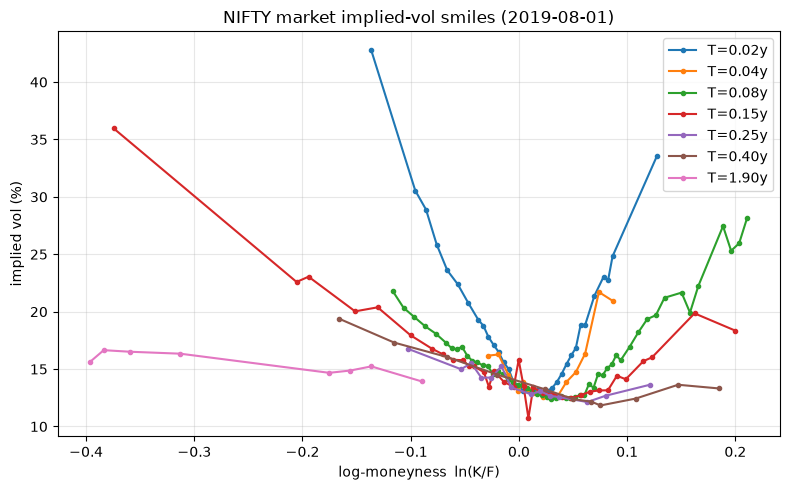

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
for T in sorted(surface.TTM.unique()):
    s = surface[surface.TTM == T].sort_values("logm")
    ax.plot(s.logm, s.iv * 100, marker="o", ms=3, label=f"T={T:.2f}y")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("implied vol (%)")
ax.set_title(f"NIFTY market implied-vol smiles ({TRADE_DATE.date()})")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [12]:
## 5. Gridded IV surface (well-covered region only)
# Fixes: drop the lone far-dated expiry (1.90y, 8 strikes, put-wing only) that distorts the
# maturity axis; restrict to a moneyness band the liquid expiries actually share; interpolate
# each smile only within its own support (no invented data).
from scipy.interpolate import interp1d

work = surface[surface.TTM <= 0.45].copy()             # drop the sparse 1.90y slice
logm_grid = np.linspace(-0.12, 0.12, 25)               # band the short expiries share
mats = np.array(sorted(work.TTM.unique()))

iv_grid = np.full((len(mats), len(logm_grid)), np.nan)
for i, T in enumerate(mats):
    s = work[work.TTM == T].sort_values("logm")
    if len(s) < 4:
        continue
    lo, hi = s.logm.min(), s.logm.max()                # only within this expiry's traded range
    f = interp1d(s.logm.values, s.iv.values, kind="linear", bounds_error=False)
    band = (logm_grid >= lo) & (logm_grid <= hi)
    iv_grid[i, band] = f(logm_grid[band])

coverage = np.isfinite(iv_grid).mean()
print(f"maturities kept: {mats} | grid coverage: {coverage:.0%}")

maturities kept: [0.019 0.036 0.077 0.153 0.249 0.403] | grid coverage: 89%


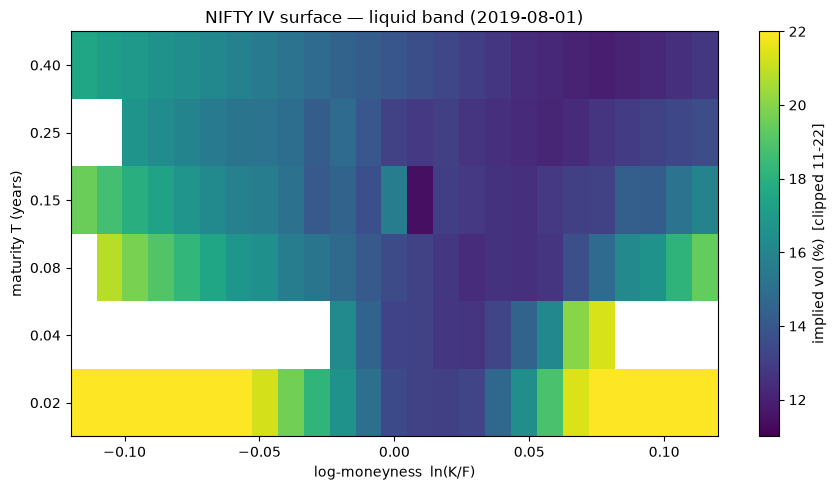

In [ ]:
# Heatmap with a clipped color scale (so short-wing spikes don't wash out the mid-surface),
# and an evenly-spaced maturity axis via row index (labels show the real T values).
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(iv_grid * 100, origin="lower", aspect="auto", cmap="viridis",
               vmin=11, vmax=22,                        # clip: the bulk of the surface
               extent=[logm_grid[0], logm_grid[-1], 0, len(mats)])
ax.set_yticks(np.arange(len(mats)) + 0.5); ax.set_yticklabels([f"{t:.2f}" for t in mats])
fig.colorbar(im, ax=ax, label="implied vol (%)  [clipped 11-22]")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("maturity T (years)")
ax.set_title(f"NIFTY IV surface - liquid band ({TRADE_DATE.date()})")
plt.tight_layout(); plt.show()

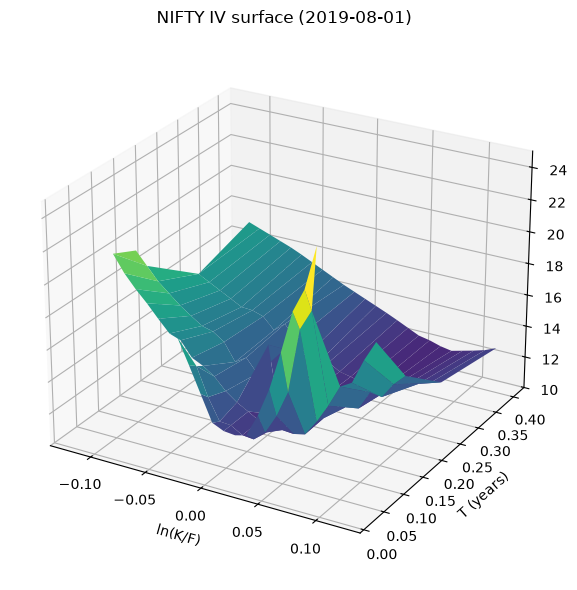

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X, Y = np.meshgrid(logm_grid, mats)
Z = np.ma.masked_invalid(iv_grid * 100)          # mask gaps so they don't render as spikes
fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", vmin=11, vmax=22, edgecolor="none")
ax.set_xlabel("ln(K/F)"); ax.set_ylabel("T (years)"); ax.set_zlabel("IV (%)")
ax.set_zlim(10, 25)                               # crop the wing spikes so the body is visible
ax.set_title(f"NIFTY IV surface ({TRADE_DATE.date()})")
ax.view_init(elev=25, azim=-60)
plt.tight_layout(); plt.show()

## 6. Numerical Heston: full-truncation Euler simulator

The core "numerical Heston" piece. We simulate the risk-neutral dynamics in log-price form
$$dX = (r - \tfrac12 v)\,dt + \sqrt{v}\,dW^S,\qquad dv = \kappa(\theta - v)\,dt + \xi\sqrt{v}\,dW^v,\qquad dW^S dW^v = \rho\,dt,$$
with the **full-truncation** fix (Lord et al. 2010): wherever $v$ appears under a square root or in the
drift, use $v^+=\max(v,0)$. This keeps the variance from going imaginary when a Euler step overshoots
below zero - the standard robust scheme, and the one that tolerates a violated Feller condition.

Paths share one fine time grid; we snapshot the terminal price at each requested maturity so the whole
term structure comes from a single consistent simulation.

In [18]:
def simulate_heston_terminals(S0, v0, kappa, theta, xi, rho, r, maturities,
                              steps_per_year=252, n_paths=100_000, seed=0):
    """Full-truncation Euler MC. Returns {maturity: array of terminal prices S_T}."""
    rng = np.random.default_rng(seed)
    mats = np.sort(np.asarray(maturities, dtype=float))
    Tmax = mats[-1]
    n_steps = int(np.ceil(Tmax * steps_per_year))
    dt = Tmax / n_steps
    sqrt_dt = np.sqrt(dt)
    # Map each maturity to the nearest step index for snapshotting.
    snap = {int(np.clip(round(T / dt), 1, n_steps)): T for T in mats}

    X = np.full(n_paths, np.log(S0))          # log-price
    v = np.full(n_paths, float(v0))           # variance
    out = {}
    for step in range(1, n_steps + 1):
        z1 = rng.standard_normal(n_paths)                       # drives variance
        z2 = rng.standard_normal(n_paths)
        zS = rho * z1 + np.sqrt(1.0 - rho * rho) * z2           # correlated price shock
        vp = np.maximum(v, 0.0)                                 # full truncation
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp) * sqrt_dt * z1
        X = X + (r - 0.5 * vp) * dt + np.sqrt(vp) * sqrt_dt * zS
        if step in snap:
            out[snap[step]] = np.exp(X).copy()
    return out

In [19]:
# Initial (un-calibrated) NIFTY-like parameters -- calibration is the next section.
heston_params = dict(S0=11100.0, v0=0.018, kappa=1.5, theta=0.020, xi=0.5, rho=-0.7, r=R)

# Validation: Feller flag, martingale E[S]/F ~= 1, and a sane ATM level / skew sign.
_mats = sorted(surface[surface.TTM <= 0.45].TTM.unique())
_term = simulate_heston_terminals(maturities=_mats, n_paths=200_000, seed=1,
                                  **{k: heston_params[k] for k in
                                     ["S0","v0","kappa","theta","xi","rho","r"]})
feller = 2*heston_params["kappa"]*heston_params["theta"] >= heston_params["xi"]**2
print(f"Feller 2*k*theta >= xi^2: {feller}  (violation is acceptable under full truncation)")
for T in _mats:
    ST = _term[T]; F = heston_params["S0"]*np.exp(heston_params["r"]*T)
    print(f"  T={T:.3f} | E[S]/F={ST.mean()/F:.4f} (martingale check)")

Feller 2*k*theta >= xi^2: False  (violation is acceptable under full truncation)
  T=0.019 | E[S]/F=1.0000 (martingale check)
  T=0.036 | E[S]/F=1.0000 (martingale check)
  T=0.077 | E[S]/F=0.9999 (martingale check)
  T=0.153 | E[S]/F=1.0000 (martingale check)
  T=0.249 | E[S]/F=1.0001 (martingale check)
  T=0.403 | E[S]/F=1.0000 (martingale check)


## 7. Model IV surface vs the market

Price the same log-moneyness grid off the simulated terminals (OTM side, discounted MC payoff), invert
Black-76 to get the **model** IV surface, and overlay it on the market smiles. With un-calibrated
parameters we expect the right *shape* (downward skew, ~13% ATM) but not a tight fit yet - that's what
calibration fixes next.

In [20]:
def heston_model_surface(params, maturities, logm_grid, n_paths=200_000, seed=1):
    """Price the (logm, T) grid under Heston and invert to a model IV table."""
    term = simulate_heston_terminals(
        maturities=maturities, n_paths=n_paths, seed=seed,
        **{k: params[k] for k in ["S0","v0","kappa","theta","xi","rho","r"]})
    S0, r = params["S0"], params["r"]
    rows = []
    for T in maturities:
        ST = term[T]; F = S0*np.exp(r*T); D = np.exp(-r*T)
        for lm in logm_grid:
            K = F*np.exp(lm)
            if K >= F:                                   # OTM call
                price, cp = D*np.mean(np.maximum(ST-K, 0.0)), "C"
            else:                                        # OTM put
                price, cp = D*np.mean(np.maximum(K-ST, 0.0)), "P"
            v = implied_vol(price, F, K, T, r, cp)
            if np.isfinite(v):
                rows.append(dict(TTM=round(T,3), logm=lm, iv=v))
    return pd.DataFrame(rows)

logm_grid = np.linspace(-0.12, 0.12, 25)
model_surface = heston_model_surface(heston_params, _mats, logm_grid)
print("model surface points:", len(model_surface))

model surface points: 139


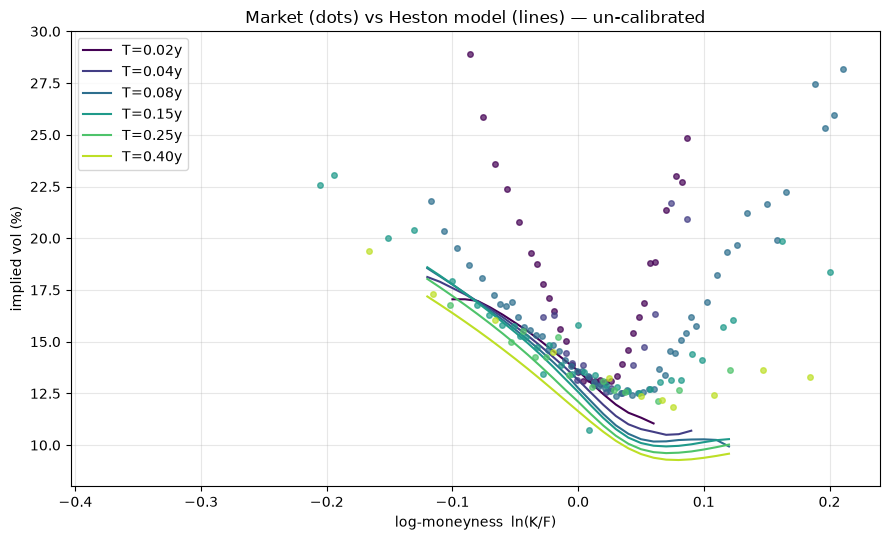

In [ ]:
# Overlay: market (dots) vs Heston model (lines), one colour per maturity.
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(_mats)))
for c, T in zip(colors, _mats):
    m = surface[surface.TTM == T].sort_values("logm")
    mo = model_surface[model_surface.TTM == round(T,3)].sort_values("logm")
    ax.plot(m.logm, m.iv*100, "o", ms=4, color=c, alpha=0.7)
    ax.plot(mo.logm, mo.iv*100, "-", color=c, label=f"T={T:.2f}y")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("implied vol (%)")
ax.set_title("Market (dots) vs Heston model (lines) - un-calibrated")
ax.grid(alpha=0.3); ax.legend(); ax.set_ylim(8, 30)
plt.tight_layout(); plt.show()

## Next steps

**Now - Calibrate.** Fit $(\kappa, \theta, \xi, \rho, v_0)$ so the model surface matches the market.
- Objective: squared IV error (model − market), weighted toward the liquid ATM region.
- Expect $\xi$ to rise (the un-calibrated model lacks wing curvature) and a mid-maturity compromise
  (one parameter set can't match the steep short smiles and flat long smiles at once - a known Heston limit).
- Use fixed common random numbers across objective evaluations (smooth objective), then re-simulate at
  high path count at the optimum.

**Then - Generate the dataset.** Sample $(\kappa, \theta, \xi, \rho, v_0)$ around the calibrated values
→ price each draw → one clean, gap-free IV surface per draw, all on the same fixed (moneyness, $T$) grid.
This stack of surfaces is the flow-matching target.

**Finally - Flow matching.** Reuse the Phase-1/2 pipeline (FM-OT / FM-Diff / SM-Diff) on the surface
dataset, adapting only the data sampler and the metrics to the surface grid.

# flow matching on the options / Heston data

The goal is to decide which application is **physically, computationally, and logically feasible**
before committing. Grouped by theme; **group 1 is the one that decides everything else.**

## 1. Framing 
- Is the Heston/options stage a **third target** for the same FM-OT / FM-Diff / SM-Diff methods
  comparison (like Phases 1–2), or a **genuine application** with its own research question?
- If an application, what is the **deliverable** - faster calibrator, scenario generator,
  arbitrage-free surface completer, or a density model of surfaces?
- What is the **novel contribution of flow matching specifically**, vs existing VAE/GAN/normalising-flow
  work on vol surfaces, or standard simulation-based inference for calibration? *(Both literatures likely
  exist and are mature - worth confirming so we don't re-solve a solved problem.)*

## 2. What object should flow matching model?
- **Surfaces themselves** → learn $p(\text{surface})$: generation / completion / anomaly detection.
  What drives variation between samples - dates? underlyings? sampled Heston params?
- **Parameters** → learn $p(\kappa,\theta,\xi,\rho,v_0)$ or the posterior $p(\text{params}\mid\text{surface})$.
  This is **amortised calibration / simulation-based inference**, not "optimisation". Goal = calibrate any
  surface instantly after one training run?
- **Forward map** → learn $p(\text{surface}\mid\text{params})$: FM as a fast neural **pricer/emulator**.
  Is pricing speed the bottleneck worth attacking?

## 3. Analytical vs numerical Heston
- For European IV surfaces the **analytical (Fourier) pricer** is faster and exact. Any reason to prefer
  slow **MC** for dataset generation (path-dependence, extensions, neural-SDE angle), or is the numerical
  scheme just a stepping stone?

## 4. Data source (the feasibility crux)
- **Synthetic** (Heston) → unlimited clean surfaces, but FM can only learn *Heston* - circular for a
  thesis, or acceptable as a controlled study?
- **Real** surfaces → few, thin, holey. How many independent surfaces exist (underlyings × dates), and is
  that enough to **train** a generative model, or only to **validate** a synthetic one?
- Intended split - real for calibration/validation, synthetic for training?

## 5. Financial validity
- Must generated surfaces be **arbitrage-free** (calendar/butterfly)? Hard constraint, penalty, or
  post-hoc projection? *(FM gives no built-in guarantee.)*
- Generate in a **helpful coordinate** - total variance $w=\sigma^2 T$, log-moneyness - instead of raw IV?
- Which must hold **exactly** vs approximately: positivity, risk-neutral consistency, martingale?

## 6. Representation, computation, evaluation
- Surface **representation** for FM - flattened vector vs image-like grid - and how are **missing cells /
  masks** handled?
- **Conditional vs unconditional** generation (condition on maturity / underlying / regime)? Where's the
  scope line?
- **Success metric** - calibration RMSE, arbitrage-violation rate, held-out likelihood, downstream pricing
  error - and **what baseline must we beat**?

---
**Through-line to propose:** the two ideas (*analytical Heston + FM for the inverse map* = amortised
calibration; *FM on surfaces* = generative prior) are not competitors but the **same conditional model
viewed forward vs backward**. This reframes "which one?" into "which direction do we start from?"

## 8. Calibration

Fit $(\kappa, \theta, \xi, \rho, v_0)$ so the model IV surface matches the market. Design choices:

- **IV-space objective, weighted toward ATM** - a Gaussian weight in log-moneyness down-weights the
  noisy short-dated wings (thin liquidity), since we care most about the well-traded region.
- **Common random numbers (fixed seed) across evaluations** - every objective call reuses the *same*
  random draws, so Monte-Carlo noise is deterministic and the optimizer sees a smooth objective rather
  than reshuffling noise. Without this, the optimizer chases MC noise and never converges.
- **Nelder-Mead from the current guess** - the guess already has the right shape; a derivative-free local
  search suffices (validated on synthetic data: it recovers known parameters to ~0.01). A global search
  would cost far more MC evaluations for no gain here.

Expect $\xi$ to rise (the un-calibrated model lacked wing curvature) and a mid-maturity compromise - one
parameter set cannot match the steep short smiles and flat long smiles simultaneously (a known Heston limit).

In [22]:
from scipy.optimize import minimize

# Precompute the market target once: (T, log-moneyness, market IV, ATM weight) per maturity.
_cal_mats = sorted(surface[surface.TTM <= 0.45].TTM.unique())
_market_target = []
for T in _cal_mats:
    s = surface[surface.TTM == T]
    lm = s.logm.values; mkt = s.iv.values
    w = np.exp(-(lm / 0.10) ** 2)                      # weight toward ATM
    _market_target.append((T, lm, mkt, w))

CALIB_PATHS, CALIB_SPY, CALIB_SEED = 40_000, 120, 0    # modest + fixed seed for calibration speed
_PNAMES = ["v0", "kappa", "theta", "xi", "rho"]
_BOUNDS = dict(v0=(0.005,0.15), kappa=(0.1,10.0), theta=(0.005,0.15), xi=(0.05,2.0), rho=(-0.98,-0.02))

def calibration_rmse(x, n_paths=CALIB_PATHS, seed=CALIB_SEED):
    """Weighted IV RMSE (vol points) between the Heston model and the market surface."""
    p = dict(zip(_PNAMES, x))
    for k, (lo, hi) in _BOUNDS.items():                # keep the search in a sane region
        if not (lo < p[k] < hi):
            return 10.0
    term = simulate_heston_terminals(
        S0=heston_params["S0"], r=heston_params["r"], maturities=_cal_mats,
        steps_per_year=CALIB_SPY, n_paths=n_paths, seed=seed, **{k: p[k] for k in _PNAMES})
    S0, r = heston_params["S0"], heston_params["r"]
    se = wsum = 0.0
    for T, lm_arr, mkt_arr, w_arr in _market_target:
        ST = term[T]; F = S0*np.exp(r*T); D = np.exp(-r*T)
        for lm, mkt, w in zip(lm_arr, mkt_arr, w_arr):
            K = F*np.exp(lm)
            price = D*np.mean(np.maximum(ST-K,0.0)) if K>=F else D*np.mean(np.maximum(K-ST,0.0))
            mv = implied_vol(price, F, K, T, r, "C" if K>=F else "P")
            if np.isfinite(mv) and np.isfinite(mkt):
                se += w*(mv-mkt)**2; wsum += w
    return np.sqrt(se/wsum)*100 if wsum > 0 else 10.0

In [23]:
import time
x0 = np.array([heston_params[k] for k in _PNAMES])     # start from the un-calibrated guess
print(f"start RMSE: {calibration_rmse(x0):.3f} vol points")

t = time.time()
res = minimize(calibration_rmse, x0, method="Nelder-Mead",
               options=dict(xatol=1e-4, fatol=1e-3, maxiter=400))
print(f"calibrated in {time.time()-t:.0f}s | evals={res.nfev} | RMSE={res.fun:.3f} vol points")

heston_params_cal = dict(heston_params)                # calibrated parameter set (for the generator)
heston_params_cal.update(dict(zip(_PNAMES, res.x)))
for k in _PNAMES:
    print(f"  {k:6s}: {heston_params[k]:+.4f}  ->  {heston_params_cal[k]:+.4f}")
print("Feller 2*k*theta >= xi^2:",
      2*heston_params_cal['kappa']*heston_params_cal['theta'] >= heston_params_cal['xi']**2)

start RMSE: 3.163 vol points
calibrated in 40s | evals=248 | RMSE=2.281 vol points
  v0    : +0.0180  ->  +0.0234
  kappa : +1.5000  ->  +1.3732
  theta : +0.0200  ->  +0.0240
  xi    : +0.5000  ->  +0.5242
  rho   : -0.7000  ->  -0.5136
Feller 2*k*theta >= xi^2: False


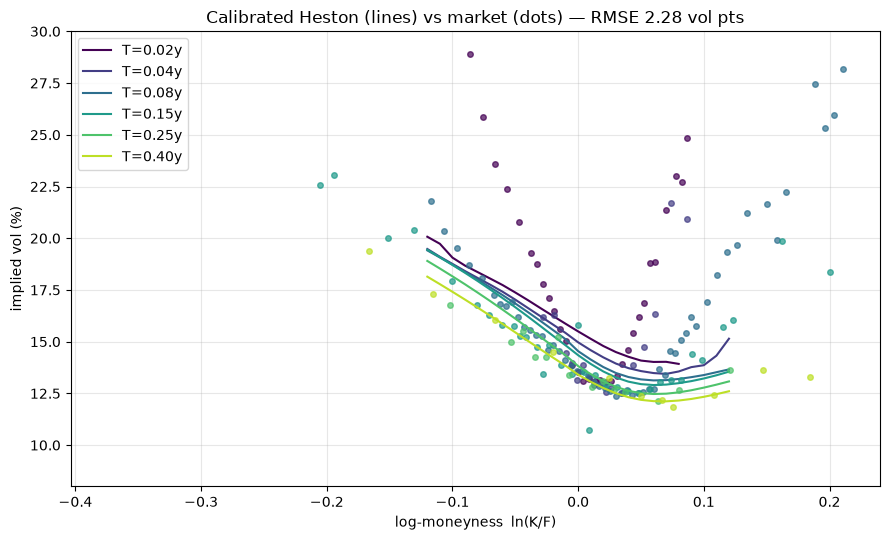

In [ ]:
# Calibrated fit: market (dots) vs calibrated Heston (lines), high path count for a clean surface.
logm_grid = np.linspace(-0.12, 0.12, 25)
model_cal = heston_model_surface(heston_params_cal, _cal_mats, logm_grid, n_paths=300_000, seed=7)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(_cal_mats)))
for c, T in zip(colors, _cal_mats):
    m  = surface[surface.TTM == T].sort_values("logm")
    mo = model_cal[model_cal.TTM == round(T,3)].sort_values("logm")
    ax.plot(m.logm,  m.iv*100,  "o", ms=4, color=c, alpha=0.7)
    ax.plot(mo.logm, mo.iv*100, "-", color=c, label=f"T={T:.2f}y")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("implied vol (%)")
ax.set_title(f"Calibrated Heston (lines) vs market (dots) - RMSE {res.fun:.2f} vol pts")
ax.grid(alpha=0.3); ax.legend(); ax.set_ylim(8, 30)
plt.tight_layout(); plt.show()

In [25]:
# Rebalanced weights: wider moneyness weight (wings count more) + per-maturity boost for the short end.
_cal_mats = sorted(surface[surface.TTM <= 0.45].TTM.unique())

def _maturity_weight(T):
    # Up-weight short maturities (the ones vanilla Heston tends to abandon). Tune the 0.15 scale.
    return 1.0 / (T + 0.05)

_market_target = []
for T in _cal_mats:
    s  = surface[surface.TTM == T]
    lm, mkt = s.logm.values, s.iv.values
    w_money = np.exp(-(lm / 0.18) ** 2)          # was 0.10 -> wider, so wings count more
    w = w_money * _maturity_weight(T)            # combine moneyness + maturity weighting
    _market_target.append((T, lm, mkt, w))

In [26]:
# Per-maturity RMSE at the calibrated optimum: shows WHERE the residual error sits.
S0, r = heston_params["S0"], heston_params["r"]
term = simulate_heston_terminals(S0=S0, r=r, maturities=_cal_mats, steps_per_year=CALIB_SPY,
                                 n_paths=200_000, seed=7, **{k: heston_params_cal[k] for k in _PNAMES})
print("per-maturity RMSE (vol pts):")
for T, lm_arr, mkt_arr, _ in _market_target:
    ST = term[T]; F = S0*np.exp(r*T); D = np.exp(-r*T); errs = []
    for lm, mkt in zip(lm_arr, mkt_arr):
        K = F*np.exp(lm)
        price = D*np.mean(np.maximum(ST-K,0.0)) if K>=F else D*np.mean(np.maximum(K-ST,0.0))
        mv = implied_vol(price, F, K, T, r, "C" if K>=F else "P")
        if np.isfinite(mv) and np.isfinite(mkt): errs.append((mv-mkt)*100)
    print(f"  T={T:.3f}y | RMSE {np.sqrt(np.mean(np.square(errs))):.2f} | n={len(errs)}")

per-maturity RMSE (vol pts):
  T=0.019y | RMSE 5.63 | n=31
  T=0.036y | RMSE 3.03 | n=17
  T=0.077y | RMSE 2.73 | n=50
  T=0.153y | RMSE 2.22 | n=35
  T=0.249y | RMSE 0.72 | n=14
  T=0.403y | RMSE 0.39 | n=11


### We couldn't fix the issue of short maturities for that, we would need to use other models apart from Vanila Heston. Use:
- Family 1 - add jumps (fixes the actual problem).
Bates (Heston + Merton jumps). This is the standard, and the right first answer to your question. It's Heston with lognormal jumps in the price: dS/S = \dots + dJ
. Jumps create sharp short-dated skew/smile that diffusion can't, and they decay with maturity - exactly the market pattern you're missing. Cost: three more parameters (jump intensity, mean, std). Your simulator extends naturally - you add a compound-Poisson term to the log-price step; the variance process is unchanged. Calibration is the same machinery with 8 parameters instead of 5. This is the one I'd recommend if you want the short end. It's well-documented and citable, and it reuses ~90% of your code.
SVJJ (jumps in price and variance). Bates plus jumps in the variance too. Marginally better at the very short end, but more parameters and harder to calibrate. Overkill for your purpose.

- Family 2 - keep pure diffusion, add time-flexibility (partial fix).

Piecewise / term-structure Heston (time-dependent κ,θ,ξ,rho\kappa,\theta,\xi,\rho
κ,θ,ξ,rho). Instead of one parameter set for all maturities, let them be piecewise-constant across maturity buckets. This directly resolves "one set can't fit 0.02y and 0.40y at once" - you fit each maturity band with its own parameters. It won't make a single short smile as steep as jumps can, but it removes the cross-maturity conflict. Moderate code change (parameters become time-indexed), and it stays pure-diffusion so your FTE simulator barely changes. Good middle option.
Double Heston (two variance factors, one fast one slow). The fast factor handles short-dated curvature, the slow one the long end. Fits term structure well, but doubles the variance state and adds ~5 parameters. More than you need.

-Family 3 - different model class (probably too far).

Rough Bergomi / rough volatility. Rough vol models (volatility driven by fractional Brownian motion, Hurst H≈0.1H \approx 0.1
H≈0.1) are specifically celebrated for matching the steep short-dated skew that Heston fails on - this is their headline selling point, and empirically they fit the short end far better. But: simulation is much harder (fractional kernels, no simple Euler scheme), calibration is slower, and it's a genuinely different model. This is a research direction in its own right, not a drop-in. Worth knowing it's the "correct" answer to steep short smiles, but likely out of scope unless your supervisor wants rough vol to be the thesis.
SABR. Popular for smiles, but it's really a per-maturity smile model, not a term-structure model - you'd fit one SABR per expiry. Fine for interpolation, wrong tool for a coherent surface generator.

## 8b. Re-scoped calibration (T ≥ 0.13)

Vanilla Heston cannot make the ultra-short smiles (0.02–0.08y) steep enough — a known one-factor
limitation (jumps/rough-vol are needed there). The per-maturity RMSE made this explicit: error decays
monotonically with maturity. We therefore calibrate on **T ≥ 0.13y**, where Heston fits well
(aggregate RMSE ≈ 0.8 vol pts), and document the short-end exclusion as a finding, not a hidden choice.

Note: the calibration band does **not** limit the dataset — a calibrated Heston prices any (K, T), so the
generated surface dataset can use a denser/wider maturity grid than the three calibration maturities.

In [27]:
# Re-scope to the maturities Heston represents faithfully.
CAL_TMIN, CAL_TMAX = 0.13, 0.45
_cal_mats = sorted(surface[(surface.TTM >= CAL_TMIN) & (surface.TTM <= CAL_TMAX)].TTM.unique())
print("calibration maturities:", [round(t,3) for t in _cal_mats])

_market_target = []
for T in _cal_mats:
    s = surface[surface.TTM == T]
    lm, mkt = s.logm.values, s.iv.values
    w = np.exp(-(lm / 0.15) ** 2)          # moderate ATM weighting
    _market_target.append((T, lm, mkt, w))

calibration maturities: [np.float64(0.153), np.float64(0.249), np.float64(0.403)]


In [28]:
import time
x0 = np.array([heston_params[k] for k in _PNAMES])
print(f"start RMSE: {calibration_rmse(x0):.3f} vol points")
t = time.time()
res = minimize(calibration_rmse, x0, method="Nelder-Mead",
               options=dict(xatol=1e-4, fatol=1e-3, maxiter=400))
print(f"calibrated in {time.time()-t:.0f}s | evals={res.nfev} | aggregate RMSE={res.fun:.3f} vol pts")

heston_params_cal = dict(heston_params)
heston_params_cal.update(dict(zip(_PNAMES, res.x)))
for k in _PNAMES:
    print(f"  {k:6s}: {heston_params[k]:+.4f}  ->  {heston_params_cal[k]:+.4f}")

# Per-maturity RMSE (shows the fit is now clean across the retained band).
S0, r = heston_params["S0"], heston_params["r"]
term = simulate_heston_terminals(S0=S0, r=r, maturities=_cal_mats, steps_per_year=CALIB_SPY,
                                 n_paths=200_000, seed=7, **{k: heston_params_cal[k] for k in _PNAMES})
print("per-maturity RMSE (vol pts):")
for T, lm_arr, mkt_arr, _ in _market_target:
    ST = term[T]; F = S0*np.exp(r*T); D = np.exp(-r*T); errs = []
    for lm, mkt in zip(lm_arr, mkt_arr):
        K = F*np.exp(lm)
        price = D*np.mean(np.maximum(ST-K,0.0)) if K>=F else D*np.mean(np.maximum(K-ST,0.0))
        mv = implied_vol(price, F, K, T, r, "C" if K>=F else "P")
        if np.isfinite(mv) and np.isfinite(mkt): errs.append((mv-mkt)*100)
    print(f"  T={T:.3f}y | RMSE {np.sqrt(np.mean(np.square(errs))):.2f} | n={len(errs)}")

start RMSE: 2.243 vol points
calibrated in 42s | evals=483 | aggregate RMSE=0.806 vol pts
  v0    : +0.0180  ->  +0.0185
  kappa : +1.5000  ->  +3.1181
  theta : +0.0200  ->  +0.0312
  xi    : +0.5000  ->  +0.8074
  rho   : -0.7000  ->  -0.3653
per-maturity RMSE (vol pts):
  T=0.153y | RMSE 1.61 | n=35
  T=0.249y | RMSE 0.63 | n=14
  T=0.403y | RMSE 0.84 | n=11


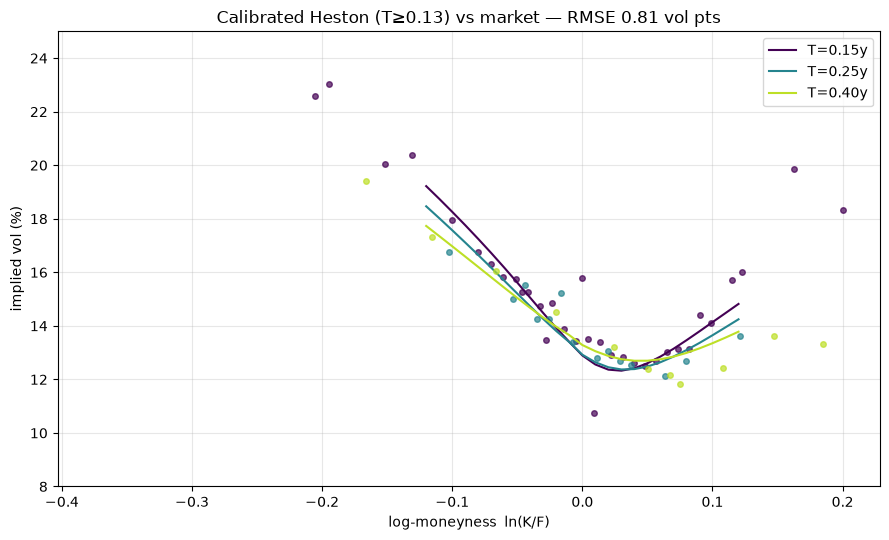

In [29]:
# Calibrated overlay on the retained band.
logm_grid = np.linspace(-0.12, 0.12, 25)
model_cal = heston_model_surface(heston_params_cal, _cal_mats, logm_grid, n_paths=300_000, seed=7)
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(_cal_mats)))
for c, T in zip(colors, _cal_mats):
    m  = surface[surface.TTM == T].sort_values("logm")
    mo = model_cal[model_cal.TTM == round(T,3)].sort_values("logm")
    ax.plot(m.logm,  m.iv*100,  "o", ms=4, color=c, alpha=0.7)
    ax.plot(mo.logm, mo.iv*100, "-", color=c, label=f"T={T:.2f}y")
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("implied vol (%)")
ax.set_title(f"Calibrated Heston (T≥0.13) vs market — RMSE {res.fun:.2f} vol pts")
ax.grid(alpha=0.3); ax.legend(); ax.set_ylim(8, 25)
plt.tight_layout(); plt.show()

## 9. rho-stability test (calibration gate)

Before building the generator we check that rho = −0.37 is a real skew estimate, not an artifact of the
35-point T=0.153 slice dominating the weighted objective. Two refits vs. the baseline:
- **A:** drop T=0.153 entirely (calibrate on T ≥ 0.24).
- **B:** keep T ≥ 0.13 but normalise weights *per maturity* so point count doesn't drive the fit.

Decision rule: if rho stays within ±0.05 across baseline/A/B, lock it. Otherwise rho is weighting-driven and
must be fixed before it sets the centre of the sampling box.

In [ ]:
# rho-stability test. Reuses the MC calibrator (apples-to-apples with §8b) by swapping the module
# globals _cal_mats / _market_target, then restoring them.
_saved = (_cal_mats, _market_target)   # snapshot the T>=0.13 config to restore afterwards

def _per_mat_rmse(pcal, cal_mats, target):
    S0, r = heston_params["S0"], heston_params["r"]
    term = simulate_heston_terminals(S0=S0, r=r, maturities=cal_mats, steps_per_year=CALIB_SPY,
                                     n_paths=200_000, seed=7, **{k: pcal[k] for k in _PNAMES})
    out = {}
    for T, lm_arr, mkt_arr, _ in target:
        ST = term[T]; F = S0*np.exp(r*T); D = np.exp(-r*T); errs = []
        for lm, mkt in zip(lm_arr, mkt_arr):
            K = F*np.exp(lm)
            price = D*np.mean(np.maximum(ST-K,0.)) if K>=F else D*np.mean(np.maximum(K-ST,0.))
            mv = implied_vol(price, F, K, T, r, "C" if K>=F else "P")
            if np.isfinite(mv): errs.append((mv-mkt)*100)
        out[T] = np.sqrt(np.mean(np.square(errs)))
    return out

def _refit(cal_mats, normalise_per_maturity):
    global _cal_mats, _market_target
    _cal_mats = cal_mats
    _market_target = []
    for T in cal_mats:
        s = surface[surface.TTM == T]; lm, mkt = s.logm.values, s.iv.values
        w = np.exp(-(lm/0.15)**2)
        if normalise_per_maturity: w = w/w.sum()          # each maturity contributes equally
        _market_target.append((T, lm, mkt, w))
    x0 = np.array([heston_params[k] for k in _PNAMES])
    res = minimize(calibration_rmse, x0, method="Nelder-Mead",
                   options=dict(xatol=1e-4, fatol=1e-3, maxiter=400))
    pcal = dict(zip(_PNAMES, res.x))
    return pcal, res.fun, _per_mat_rmse({**heston_params, **pcal}, cal_mats, _market_target)

try:
    rho_base = heston_params_cal["rho"]
    mats_A = sorted(surface[(surface.TTM >= 0.24) & (surface.TTM <= 0.45)].TTM.unique())
    mats_B = sorted(surface[(surface.TTM >= 0.13) & (surface.TTM <= 0.45)].TTM.unique())

    print("config              rho      aggRMSE   per-maturity RMSE")
    print(f"baseline (T>=.13)  {rho_base:+.3f}      —      (see §8b)")
    for name, (pcal, agg, pm) in [
        ("A  drop T=.153   ", _refit(mats_A, False)),
        ("B  norm weights  ", _refit(mats_B, True)),
    ]:
        pm_str = " ".join(f"{t:.2f}:{r:.2f}" for t, r in pm.items())
        print(f"{name}{pcal['rho']:+.3f}   {agg:6.3f}   {pm_str}")

    rhos = [rho_base, _refit(mats_A, False)[0]["rho"], _refit(mats_B, True)[0]["rho"]]
    spread = max(rhos) - min(rhos)
    print(f"\nrho spread across baseline/A/B: {spread:.3f}")
    print("VERDICT:", "LOCK rho — stable" if spread <= 0.05
          else "rho is weighting-driven — recentre box on a normalised-weight refit before generating")
finally:
    _cal_mats, _market_target = _saved            # restore §8b state

config              rho      aggRMSE   per-maturity RMSE
baseline (T>=.13)  -0.365      —      (see §8b)
A  drop T=.153   -0.472    0.445   0.25:0.49 0.40:0.34
B  norm weights  -0.406    0.728   0.15:1.86 0.25:0.54 0.40:0.61

ρ spread across baseline/A/B: 0.107
VERDICT: ρ is weighting-driven — recentre box on a normalised-weight refit before generating


## 10. Analytical Heston pricer (Fourier) for bulk generation

MC is validated but too slow/noisy to generate thousands of clean surfaces. We switch to the exact
Fourier pricer (Heston 1993; Albrecher et al. 2007 "little trap" branch fix) for European surfaces,
and keep the MC simulator as the cross-check below. `phi_max=400, n_phi=4096` are set to resolve the
short-maturity deep-call wing (lower settings leave NaNs there).

In [31]:
def heston_calls_vec(params, K_arr, T, phi_max=400.0, n_phi=4096):
    """Exact Heston call prices for an array of strikes at one maturity (trap formulation)."""
    S0, r = params["S0"], params["r"]; v0, kappa, theta, xi, rho = (params[k] for k in _PNAMES)
    phi = np.linspace(1e-8, phi_max, n_phi); dphi = np.diff(phi)
    def fj(j):
        u = 0.5 if j == 1 else -0.5; b = (kappa - rho*xi) if j == 1 else kappa; a = kappa*theta
        rspi = rho*xi*1j*phi
        d = np.sqrt((rspi - b)**2 - xi**2*(2*u*1j*phi - phi**2))
        g = (b - rspi - d)/(b - rspi + d); edt = np.exp(-d*T)          # trap: reciprocal g
        D = (b - rspi - d)/(xi**2)*(1 - edt)/(1 - g*edt)
        C = r*1j*phi*T + a/(xi**2)*((b - rspi - d)*T - 2*np.log((1 - g*edt)/(1 - g)))
        return np.exp(C + D*v0 + 1j*phi*np.log(S0))
    lnK = np.log(np.atleast_1d(K_arr).astype(float))
    def Pj(j):
        f = fj(j); integ = np.real(np.exp(-1j*phi[:,None]*lnK[None,:])*(f/(1j*phi))[:,None])
        return 0.5 + np.sum(0.5*(integ[1:] + integ[:-1])*dphi[:,None], axis=0)/np.pi   # trapezoid
    return S0*Pj(1) - np.atleast_1d(K_arr)*np.exp(-r*T)*Pj(2)

def heston_iv_smile(params, T, logm_grid, phi_max=400.0, n_phi=4096):
    """Analytical model IV smile at one maturity. OTM puts via put-call parity."""
    S0, r = params["S0"], params["r"]; F = S0*np.exp(r*T); K = F*np.exp(logm_grid); D = np.exp(-r*T)
    calls = heston_calls_vec(params, K, T, phi_max, n_phi)
    out = np.full(len(logm_grid), np.nan)
    for i, (Kv, c) in enumerate(zip(K, calls)):
        price, cp = (c, "C") if Kv >= F else (c - D*(F - Kv), "P")
        out[i] = implied_vol(price, F, Kv, T, r, cp)
    return out

# Cross-check: analytical vs MC on the calibrated params (should agree to MC noise ~0.1-0.3 vp).
_chk_mats = [0.153, 0.403]; _chk_lm = np.linspace(-0.12, 0.12, 7)
_term = simulate_heston_terminals(maturities=_chk_mats, n_paths=300_000, steps_per_year=252, seed=1,
                                  **{k: heston_params_cal[k] for k in ["S0","v0","kappa","theta","xi","rho","r"]})
_maxd = 0.0
for T in _chk_mats:
    ST = _term[T]; F = heston_params_cal["S0"]*np.exp(heston_params_cal["r"]*T); D = np.exp(-heston_params_cal["r"]*T)
    iv_an = heston_iv_smile(heston_params_cal, T, _chk_lm)
    for lm, va in zip(_chk_lm, iv_an):
        K = F*np.exp(lm)
        price = D*np.mean(np.maximum(ST-K,0.)) if K>=F else D*np.mean(np.maximum(K-ST,0.))
        vm = implied_vol(price, F, K, T, heston_params_cal["r"], "C" if K>=F else "P")
        if np.isfinite(va) and np.isfinite(vm): _maxd = max(_maxd, abs(va-vm)*100)
print(f"analytical vs MC: max |diff| = {_maxd:.3f} vol points  (pricer validated)")

analytical vs MC: max |diff| = 0.114 vol points  (pricer validated)


## 11. Dataset generator (flow-matching target)

Sample (v0, κ, θ, ξ, ρ) in a box around the calibrated params, price each draw on a **fixed** (moneyness, T)
grid via the analytical pricer, and stack into gap-free surfaces. The grid is independent of the 3
calibration maturities — a calibrated Heston prices any (K, T). Box widths and grid below are design
choices; tune them. QC reports NaN and calendar-arbitrage rates.

In [32]:
# ---- config (tune these) ----
SEED       = 42
N_SURFACES = 1500                                   # ~6-8 min at 4096 phi nodes
LOGM_GRID  = np.linspace(-0.15, 0.15, 21)
T_GRID     = np.array([0.08, 0.17, 0.25, 0.50, 0.75, 1.00])
# box: ("mul", h) -> center*exp(U(-h,h)) [log-uniform, for positive skewed params]; ("add",(lo,hi)) uniform
BOX = dict(v0=("mul",0.4), kappa=("mul",0.5), theta=("mul",0.5), xi=("mul",0.4), rho=("add",(-0.70,-0.05)))

rng = np.random.default_rng(SEED); _c = heston_params_cal
def _sample_params():
    p = dict(S0=_c["S0"], r=_c["r"])
    for k in _PNAMES:
        kind, spec = BOX[k]
        val = _c[k]*np.exp(rng.uniform(-spec, spec)) if kind == "mul" else rng.uniform(*spec)
        p[k] = float(np.clip(val, *_BOUNDS[k]))
    return p

surfaces, params, tries = [], [], 0
while len(surfaces) < N_SURFACES:
    tries += 1; p = _sample_params()
    surf = np.stack([heston_iv_smile(p, T, LOGM_GRID) for T in T_GRID])
    if np.isnan(surf).any():                         # reject rare pricing failures -> gap-free dataset
        continue
    surfaces.append(surf); params.append([p[k] for k in _PNAMES])
surfaces = np.array(surfaces)                         # (N, n_T, n_logm)
params   = np.array(params)                           # (N, 5)

# QC
w = surfaces**2 * T_GRID[None, :, None]               # total variance
cal_viol = (np.diff(w, axis=1) < -1e-6).mean()        # calendar arb: w must rise with T
print(f"kept {len(surfaces)}/{tries} draws | shape {surfaces.shape}")
print(f"IV {surfaces.min()*100:.1f}-{surfaces.max()*100:.1f}% | calendar-arb cells {cal_viol:.2%}")
print("param ranges: " + " ".join(
    f"{k}[{params[:,i].min():.3f},{params[:,i].max():.3f}]" for i,k in enumerate(_PNAMES)))

np.savez("heston_fm_dataset.npz", surfaces=surfaces, params=params,
         logm_grid=LOGM_GRID, T_grid=T_GRID, pnames=np.array(_PNAMES),
         center=np.array([_c[k] for k in _PNAMES]))
print("saved -> heston_fm_dataset.npz")

kept 1500/1526 draws | shape (1500, 6, 21)
IV 8.1-27.0% | calendar-arb cells 0.00%
param ranges: v0[0.012,0.028] kappa[1.892,5.141] theta[0.019,0.051] xi[0.542,1.204] rho[-0.700,-0.050]
saved -> heston_fm_dataset.npz


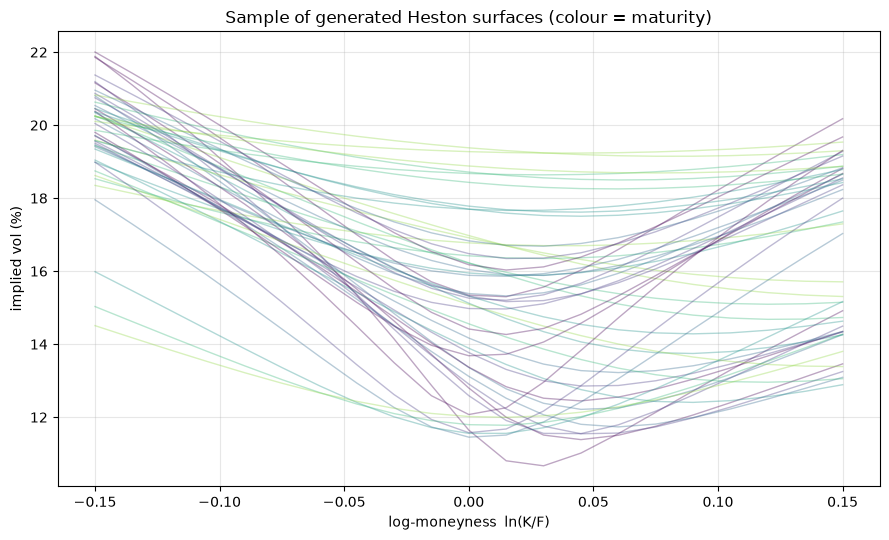

In [33]:
# Sanity: overlay a few generated surfaces (one line per maturity, faded across samples).
fig, ax = plt.subplots(figsize=(9, 5.5))
for n in rng.choice(len(surfaces), size=min(8, len(surfaces)), replace=False):
    for j, T in enumerate(T_GRID):
        ax.plot(LOGM_GRID, surfaces[n, j]*100, color=plt.cm.viridis(j/len(T_GRID)), alpha=0.35, lw=1)
ax.set_xlabel("log-moneyness  ln(K/F)"); ax.set_ylabel("implied vol (%)")
ax.set_title("Sample of generated Heston surfaces (colour = maturity)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [34]:
# Adopt config A (T>=0.24) as calibration of record: tightest fit, skew set only by maturities
# Heston represents faithfully. Capture all 5 params, show the shift, recenter the generator box.
_saved = (_cal_mats, _market_target)
mats_A = sorted(surface[(surface.TTM >= 0.24) & (surface.TTM <= 0.45)].TTM.unique())
pA, aggA, pmA = _refit(mats_A, False)
_cal_mats, _market_target = _saved                      # restore §8b state

print("param       baseline(T>=.13)   config A (T>=.24)")
for k in _PNAMES:
    print(f"  {k:6s}     {heston_params_cal[k]:+.4f}          {pA[k]:+.4f}")
heston_params_cal = {**heston_params_cal, **pA}         # recenter the box on config A
print(f"\nheston_params_cal updated | aggregate RMSE {aggA:.3f} vol pts "
      f"on T={[round(t,2) for t in mats_A]}")
print("Now re-run the §11 generator cell to regenerate on the recentred box.")

param       baseline(T>=.13)   config A (T>=.24)
  v0         +0.0185          +0.0192
  kappa      +3.1181          +1.4942
  theta      +0.0312          +0.0342
  xi         +0.8074          +0.5025
  rho        -0.3653          -0.4724

heston_params_cal updated | aggregate RMSE 0.445 vol pts on T=[np.float64(0.25), np.float64(0.4)]
Now re-run the §11 generator cell to regenerate on the recentred box.


## 12. Dataset diagnostics (config-A center)

Validate the regenerated dataset as a flow-matching target: (1) re-confirm the analytical pricer at the
new centre against MC, (2) full arbitrage QC — NaN, calendar (total variance ↑ in T), butterfly
(call convexity in K), (3) confirm the dataset brackets the calibrated surface, (4) skew sanity.

In [37]:
_atm = int(np.argmin(np.abs(LOGM_GRID)))
c = heston_params_cal

# (1) pricer re-validation at the config-A centre (short/mid/long)
_m = [0.08, 0.25, 1.0]; _lm = np.linspace(-0.12, 0.12, 7)
_t = simulate_heston_terminals(maturities=_m, n_paths=400_000, seed=1,
        **{k: c[k] for k in ["S0","v0","kappa","theta","xi","rho","r"]})
_maxd = 0.0
for T in _m:
    ST = _t[T]; F = c["S0"]*np.exp(c["r"]*T); D = np.exp(-c["r"]*T); ivan = heston_iv_smile(c, T, _lm)
    for lm, va in zip(_lm, ivan):
        K = F*np.exp(lm); pr = D*np.mean(np.maximum(ST-K,0.)) if K>=F else D*np.mean(np.maximum(K-ST,0.))
        vm = implied_vol(pr, F, K, T, c["r"], "C" if K>=F else "P")
        if np.isfinite(va) and np.isfinite(vm): _maxd = max(_maxd, abs(va-vm)*100)
print(f"(1) analytical vs MC @ A: max|diff|={_maxd:.3f} vp "
      f"| Feller 2kθ/ξ²={2*c['kappa']*c['theta']/c['xi']**2:.3f}")

# (2) arbitrage QC on the saved dataset
nan_rate = np.isnan(surfaces).mean()
w = surfaces**2 * T_GRID[None,:,None]; cal_viol = (np.diff(w, axis=1) < -1e-6).mean()
but_bad = slope_bad = tot = tot_s = 0
for n in range(len(surfaces)):
    for j, T in enumerate(T_GRID):
        F = c["S0"]*np.exp(c["r"]*T); K = F*np.exp(LOGM_GRID); D = np.exp(-c["r"]*T)
        C = np.array([black76(F, Kv, T, c["r"], surfaces[n,j,i], "C") for i, Kv in enumerate(K)])
        d1 = np.diff(C)/np.diff(K); d2 = np.diff(d1)/(0.5*(K[2:]-K[:-2]))
        slope_bad += np.sum((d1 > 1e-6) | (d1 < -D-1e-6)); but_bad += np.sum(d2 < -1e-6)
        tot += len(d2); tot_s += len(d1)
print(f"(2) NaN={nan_rate:.2%} | calendar-arb={cal_viol:.2%} | butterfly={but_bad/tot:.2%} | slope={slope_bad/tot_s:.2%}")

(1) analytical vs MC @ A: max|diff|=0.342 vp | Feller 2kθ/ξ²=0.405
(2) NaN=0.00% | calendar-arb=0.00% | butterfly=0.00% | slope=0.00%


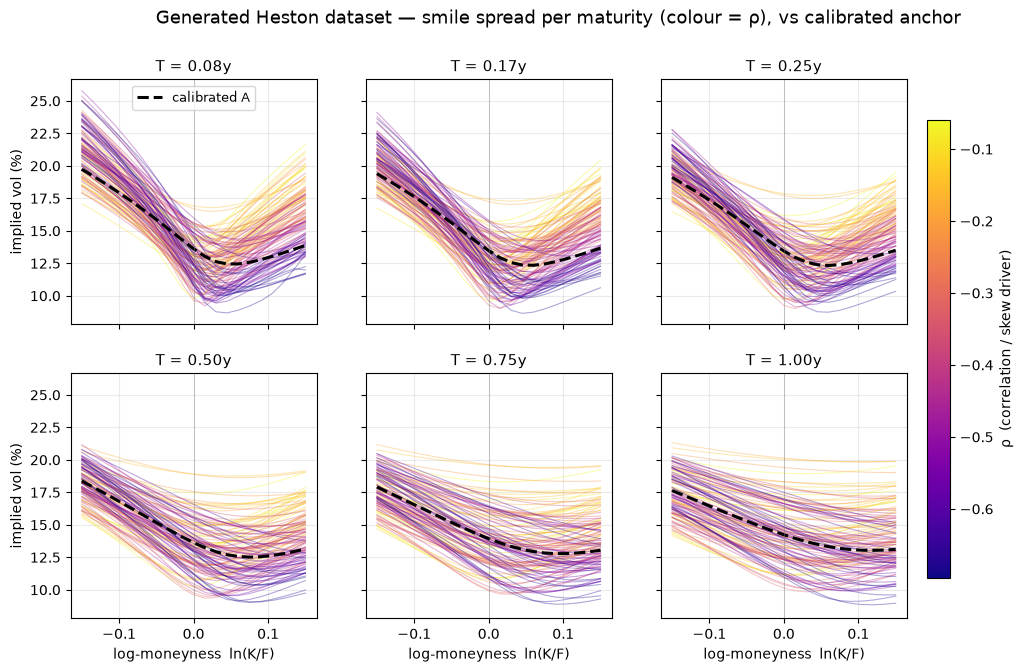

In [38]:
# Diagnostic plot: smile spread faceted by maturity, coloured by ρ, vs the calibrated anchor.
n_show = min(120, len(surfaces))
idx = rng.choice(len(surfaces), n_show, replace=False)      # rng from §11; or np.random.default_rng(0)
rho_vals = params[idx, 4]                                    # column 4 = rho in _PNAMES order
norm_rho = plt.Normalize(rho_vals.min(), rho_vals.max()); cmap = plt.cm.plasma
A_surf = np.stack([heston_iv_smile(heston_params_cal, T, LOGM_GRID) for T in T_GRID])

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for j, (T, ax) in enumerate(zip(T_GRID, axes.ravel())):
    for n in idx[np.argsort(-params[idx, 4])]:              # steep-skew lines drawn on top
        ax.plot(LOGM_GRID, surfaces[n, j]*100, color=cmap(norm_rho(params[n, 4])), alpha=0.35, lw=0.8)
    ax.plot(LOGM_GRID, A_surf[j]*100, "--", color="k", lw=2.2, label="calibrated A")
    ax.set_title(f"T = {T:.2f}y", fontsize=11); ax.grid(alpha=0.25); ax.axvline(0, color="grey", lw=0.6, alpha=0.5)
    if j == 0: ax.legend(loc="upper center", fontsize=9)
for ax in axes[-1]: ax.set_xlabel("log-moneyness  ln(K/F)")
for ax in axes[:, 0]: ax.set_ylabel("implied vol (%)")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_rho); sm.set_array([])
cb = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02); cb.set_label("ρ  (correlation / skew driver)")
fig.suptitle("Generated Heston dataset — smile spread per maturity (colour = ρ), vs calibrated anchor", fontsize=13)
plt.show()

# Layer 2 — Flow Matching over Heston IV surfaces (Phase 3)

**What this does.** Learns a generative model over the surface dataset from Layer 1. A neural velocity
field is trained to transport Gaussian noise → IV surface; integrating that field (an ODE) generates
new surfaces.

**Why it ports cleanly from Phase 2.** Flow matching is dimension-agnostic — the checkerboard was 2-D,
a surface is a 126-D vector (6 maturities × 21 moneyness). The *only* things that change:
1. **Data** — a *finite* dataset (sample minibatches from it) replaces the checkerboard's infinite generator.
2. **Model I/O** — 2 → 126 dims; drop the x-Fourier features (they existed for the checkerboard's sharp
   edges; IV surfaces are smooth).
3. **Batch samplers** — `x1 ~ sample_surface_batch` instead of `sample_checkerboard`.
4. **Metrics** — arbitrage + surface marginals replace checkerboard masses; MMD²/sliced-W carry over.

Three methods, same as Phases 1–2: **FM-OT** (optimal-transport path), **FM-Diff** (variance-preserving
diffusion path, velocity target), **SM-Diff** (same path, score target). The comparison *is* Phase 3.

In [41]:
import math, time
import numpy as np, torch, torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42; torch.manual_seed(SEED)
if device.type == "cuda": torch.cuda.manual_seed_all(SEED)

# Market context for the arbitrage metric — MUST match the Layer-1 calibration that made the dataset.
S0_REF, R_REF = 11100.0, 0.054

# Optimisation config — identical to Phase 2 so the three phases are directly comparable.
HIDDEN_DIM, NUM_HIDDEN_LAYERS = 512, 5
LEARNING_RATE      = 5e-4
NUM_TRAINING_STEPS = 20_000
BATCH_SIZE         = 2_048
LOG_EVERY          = 200

# Path hyperparameters (unchanged from Phase 2)
SIGMA_MIN = 1e-4                                       # FM-OT: residual std at the data endpoint
VP_BETA_MIN, VP_BETA_MAX, VP_EPSILON = 0.1, 20.0, 1e-5  # FM-Diff / SM-Diff: VP diffusion schedule
print("device:", device)

device: cuda


In [42]:
import math, time
import numpy as np, torch, torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42; torch.manual_seed(SEED)
if device.type == "cuda": torch.cuda.manual_seed_all(SEED)

# Market context for the arbitrage metric — MUST match the Layer-1 calibration that made the dataset.
S0_REF, R_REF = 11100.0, 0.054

# Optimisation config — identical to Phase 2 so the three phases are directly comparable.
HIDDEN_DIM, NUM_HIDDEN_LAYERS = 512, 5
LEARNING_RATE      = 5e-4
NUM_TRAINING_STEPS = 20_000
BATCH_SIZE         = 2_048
LOG_EVERY          = 200

# Path hyperparameters (unchanged from Phase 2)
SIGMA_MIN = 1e-4                                       # FM-OT: residual std at the data endpoint
VP_BETA_MIN, VP_BETA_MAX, VP_EPSILON = 0.1, 20.0, 1e-5  # FM-Diff / SM-Diff: VP diffusion schedule
print("device:", device)

device: cuda


## 1. Data module — the finite-dataset swap

**Concept.** The checkerboard sampler could draw *infinitely many* fresh points, so the FM loss was an
unbiased Monte-Carlo estimate of the true objective. Here the target is a **fixed set** of surfaces, so
`x1` is drawn from the empirical distribution: sample minibatches (with replacement) from the training
split. This is the standard finite-data FM setup.

**Normalisation.** FM's source is N(0, I), so the target should be standardised for the transport paths
to be well-scaled. We **z-score per grid point** (not globally): short-maturity wings sit at ~18–25 vol
and long-dated ATM at ~13 — different scales, so a shared mean/std would under-serve the wings. Train
statistics only; store them to invert (`denorm`) at generation time.

**Held-out split.** 15% of surfaces are never trained on — MMD²/sliced-W are computed against this split
so they measure *generalisation*, not memorisation.

In [43]:
_d = np.load("heston_fm_dataset.npz")                 # from Layer-1 §11
surf_raw  = _d["surfaces"].astype(np.float32)         # (N, nT, nK) implied vols
T_GRID    = _d["T_grid"]                              # maturities (years)
LOGM_GRID = _d["logm_grid"]                           # log-moneyness ln(K/F)
N, nT, nK = surf_raw.shape
DATA_DIM  = nT * nK                                   # 6*21 = 126 flattened dims
ATM_J     = int(np.argmin(np.abs(LOGM_GRID)))         # index of the ATM column (logm≈0)

X = surf_raw.reshape(N, DATA_DIM)                     # flatten each surface to a 126-vector

# train / val split
_g = np.random.default_rng(SEED); perm = _g.permutation(N); n_val = int(0.15 * N)
Xtr  = torch.tensor(X[perm[n_val:]], device=device)
Xval = torch.tensor(X[perm[:n_val]], device=device)

# per-grid-point z-score (train stats only)
surf_mean = Xtr.mean(0, keepdim=True)
surf_std  = Xtr.std(0, keepdim=True).clamp_min(1e-6)
Xtr_n  = (Xtr  - surf_mean) / surf_std
Xval_n = (Xval - surf_mean) / surf_std

def sample_surface_batch(n, device):
    """Draw n surfaces from the (normalised) training set — the empirical data distribution."""
    return Xtr_n[torch.randint(0, Xtr_n.shape[0], (n,), device=device)]

def denorm(x_n):
    """normalised 126-vector -> IV surface (M, nT, nK). Inverse of the z-score."""
    return (x_n * surf_std + surf_mean).reshape(-1, nT, nK)

print(f"N={N} | DATA_DIM={DATA_DIM} ({nT}x{nK}) | train={Xtr_n.shape[0]} val={Xval_n.shape[0]}")
print(f"post-norm: mean~{Xtr_n.mean():.3f} std~{Xtr_n.std():.3f}  (want ~0, ~1)")
if N < 8000:
    print(f"WARNING: {N} surfaces is thin for a {DATA_DIM}-D target — FM can memorise. "
          f"Regenerate ~10-20k in Layer-1 §11 before serious training.")

N=1500 | DATA_DIM=126 (6x21) | train=1275 val=225
post-norm: mean~0.000 std~1.000  (want ~0, ~1)


## 2. Velocity network

**Concept.** The model `v_θ(x, t)` predicts the velocity that moves a point `x` at path-time `t` toward
the data. It takes the current 126-D state plus the scalar time.

**Why x-Fourier features are gone.** Phase 2 fed `[x, FourierFeatures(x), t, FourierFeatures(t)]` — the
random Fourier features on `x` let the MLP fit the checkerboard's *sharp cell edges*. An IV surface is
smooth in both moneyness and maturity, so high-frequency x-features add nothing and can inject noise.
We keep **time**-Fourier features (time conditioning still benefits) and feed raw `x`. If the wings
underfit later, re-adding low-`scale` x-Fourier is the first knob — not the default.

In [44]:
class FourierFeatures(nn.Module):
    """v -> [sin(2π v·B), cos(2π v·B)] with fixed random B. 'scale' sets the frequency band."""
    def __init__(self, in_dim, num_freq, scale):
        super().__init__()
        self.register_buffer("B", torch.randn(in_dim, num_freq) * scale)   # fixed, saves with model
    def forward(self, v):
        proj = 2 * math.pi * (v @ self.B)
        return torch.cat([proj.sin(), proj.cos()], dim=-1)

class SurfaceMLP(nn.Module):
    """SiLU MLP over [raw x, t, FourierFeatures(t)] -> velocity in R^126."""
    def __init__(self, dim, hidden, n_layers, t_num_freq=32, t_scale=5.0):
        super().__init__()
        self.t_features = FourierFeatures(1, t_num_freq, t_scale)          # time features only
        in_dim = dim + 1 + 2 * t_num_freq                                 # raw x + raw t + FF(t)
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, dim)]
        self.network = nn.Sequential(*layers)
    def forward(self, x, t):
        return self.network(torch.cat([x, t, self.t_features(t)], dim=-1))

def build_model():
    return SurfaceMLP(DATA_DIM, HIDDEN_DIM, NUM_HIDDEN_LAYERS).to(device)

def velocity_matching_loss(pred, target):
    """Mean squared L2 velocity error, summed over the 126 coordinates."""
    return (pred - target).square().sum(dim=-1).mean()

## 3. FM-OT — optimal-transport path

**Concept.** The conditional path is a straight line from noise `x0` to data `x1`:
`ψ_t(x0) = (1 − (1−σ_min)·t)·x0 + t·x1`, with constant target velocity `u = x1 − (1−σ_min)·x0`
(independent of t → straight, constant-speed trajectories, cheap to integrate).

The training loop is a shared helper (`train`) reused by all three methods — same Adam, lr, step count,
and frozen-validation logic as Phase 2, just deduplicated. Each method supplies its own `batch_fn`
(what a minibatch is) and `loss_fn`.

In [45]:
def sample_source(n, device):
    """Source distribution p0 = N(0, I) in R^126."""
    return torch.randn(n, DATA_DIM, device=device)

def fm_ot_state(x0, x1, t, sm=SIGMA_MIN):
    return (1.0 - (1.0 - sm) * t) * x0 + t * x1        # point on the OT path at time t

def fm_ot_target_velocity(x0, x1, sm=SIGMA_MIN):
    return x1 - (1.0 - sm) * x0                        # constant conditional target velocity

def sample_fm_ot_batch(bs, device):
    x0 = sample_source(bs, device)
    x1 = sample_surface_batch(bs, device)              # <-- the swap: surfaces, not checkerboard
    t  = torch.rand(bs, 1, device=device)
    return x0, x1, t, fm_ot_state(x0, x1, t), fm_ot_target_velocity(x0, x1)

def train(model, batch_fn, loss_fn, tag, steps=NUM_TRAINING_STEPS):
    """Shared simulation-free training loop. batch_fn/loss_fn make it method-specific."""
    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    hist = {"step": [], "train": [], "val": []}
    torch.manual_seed(SEED + 1); val = batch_fn(4096, device); torch.manual_seed(SEED)  # frozen val batch
    t0 = time.time()
    for step in range(1, steps + 1):
        model.train()
        loss = loss_fn(model, batch_fn(BATCH_SIZE, device))
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        if step % LOG_EVERY == 0 or step == 1:
            model.eval()
            with torch.no_grad(): vl = loss_fn(model, val)
            hist["step"].append(step); hist["train"].append(loss.item()); hist["val"].append(vl.item())
            print(f"[{tag}] {step:5d}/{steps} | train {loss.item():.3f} | val {vl.item():.3f} | {time.time()-t0:5.0f}s")
    return hist

def fm_ot_loss(model, batch):
    _, _, t, xt, ut = batch
    return velocity_matching_loss(model(xt, t), ut)

fm_ot_model = build_model()
print("trainable params:", sum(p.numel() for p in fm_ot_model.parameters()))
fm_ot_history = train(fm_ot_model, sample_fm_ot_batch, fm_ot_loss, "FM-OT")

trainable params: 1213566
[FM-OT]     1/20000 | train 249.538 | val 250.577 |     1s
[FM-OT]   200/20000 | train 157.404 | val 155.490 |     1s
[FM-OT]   400/20000 | train 151.956 | val 153.153 |     1s
[FM-OT]   600/20000 | train 141.593 | val 138.300 |     2s
[FM-OT]   800/20000 | train 111.184 | val 109.390 |     2s
[FM-OT]  1000/20000 | train 95.661 | val 95.066 |     3s
[FM-OT]  1200/20000 | train 85.909 | val 84.228 |     3s
[FM-OT]  1400/20000 | train 77.546 | val 77.234 |     4s
[FM-OT]  1600/20000 | train 72.822 | val 69.975 |     4s
[FM-OT]  1800/20000 | train 65.597 | val 66.137 |     5s
[FM-OT]  2000/20000 | train 62.963 | val 61.726 |     5s
[FM-OT]  2200/20000 | train 58.590 | val 58.377 |     6s
[FM-OT]  2400/20000 | train 56.756 | val 54.905 |     6s
[FM-OT]  2600/20000 | train 52.463 | val 53.480 |     6s
[FM-OT]  2800/20000 | train 51.378 | val 51.042 |     7s
[FM-OT]  3000/20000 | train 50.314 | val 49.518 |     7s
[FM-OT]  3200/20000 | train 49.418 | val 47.344 |   

## 4. ODE samplers

**Concept.** Generation = integrate `dx/dt = v_θ(x, t)` from t=0 (noise) to t=1 (data). Euler is
fixed-step (NFE = num_steps); dopri5 is adaptive (accurate reference). Both are dimension-agnostic, so
these are verbatim from Phase 2.

In [46]:
from torchdiffeq import odeint

class NeuralODEFunction(nn.Module):
    """Adapts v_θ to torchdiffeq's f(t, x) signature and counts function evals (NFE)."""
    def __init__(self, model): super().__init__(); self.model = model; self.nfe = 0
    def forward(self, t, x):
        self.nfe += 1
        return self.model(x, torch.ones(x.shape[0], 1, device=x.device, dtype=x.dtype) * t)

@torch.no_grad()
def euler_integrate(model, x0, num_steps, t_end=1.0):
    model.eval(); x = x0.clone(); dt = t_end / num_steps
    for k in range(num_steps):
        t = torch.full((x.shape[0], 1), k * dt, device=x.device, dtype=x.dtype)
        x = x + dt * model(x, t)
    return x

@torch.no_grad()
def dopri5_integrate(model, x0, t_end=1.0, atol=1e-5, rtol=1e-5):
    model.eval(); fn = NeuralODEFunction(model).to(x0.device); fn.nfe = 0
    times = torch.tensor([0.0, t_end], device=x0.device, dtype=x0.dtype)
    return odeint(fn, x0, times, method="dopri5", atol=atol, rtol=rtol)[-1], fn.nfe

## 5. FM-Diff & SM-Diff — variance-preserving diffusion path

**Concept.** Instead of a straight line, the path follows a VP diffusion: `xt = α(t)·x1 + σ(t)·x0`,
where α/σ come from the noise schedule (α: 0→1, σ: 1→0 as t: 0→1). Two ways to learn it:

- **FM-Diff** — regress the network directly onto the VP probability-flow **velocity**.
- **SM-Diff** — regress onto the **score** (∝ noise direction), then convert score→velocity at sample
  time. Same path, different target; the comparison tests which parameterisation trains better.

Path math is verbatim from Phase 2 — the *only* change is `x1 ~ sample_surface_batch` in the two
batch samplers. `t` is capped at `1−ε` to avoid the singular data endpoint (σ→0).

In [48]:
def vp_beta(s): return VP_BETA_MIN + s * (VP_BETA_MAX - VP_BETA_MIN)
def vp_integrated_beta(s): return s * VP_BETA_MIN + 0.5 * s.square() * (VP_BETA_MAX - VP_BETA_MIN)
def vp_path_coefficients(t):
    """s = 1−t (reverse time). Returns (s, β, α, σ) for the VP path."""
    s = 1.0 - t
    alpha = torch.exp(-0.5 * vp_integrated_beta(s))
    sigma = torch.sqrt(torch.clamp(1.0 - alpha.square(), min=1e-12))
    return s, vp_beta(s), alpha, sigma

def fm_diff_state(x0, x1, t):
    _, _, a, sg = vp_path_coefficients(t); return a * x1 + sg * x0          # noise at t=0, data at t=1
def fm_diff_target_velocity(x0, x1, t):
    _, b, a, sg = vp_path_coefficients(t); return 0.5 * b * (a * x1 - (a.square() / sg) * x0)

def sample_fm_diff_batch(bs, device):
    x0 = sample_source(bs, device)
    x1 = sample_surface_batch(bs, device)              # <-- swap
    t  = torch.rand(bs, 1, device=device) * (1.0 - VP_EPSILON)
    return x0, x1, t, fm_diff_state(x0, x1, t), fm_diff_target_velocity(x0, x1, t)

def fm_diff_loss(model, batch):
    _, _, t, xt, ut = batch; return velocity_matching_loss(model(xt, t), ut)

FM_DIFF_END_TIME = 1.0 - VP_EPSILON
fm_diff_model = build_model()
fm_diff_history = train(fm_diff_model, sample_fm_diff_batch, fm_diff_loss, "FM-Diff")

[FM-Diff]     1/20000 | train 468.626 | val 458.434 |     0s
[FM-Diff]   200/20000 | train 318.461 | val 314.854 |     1s
[FM-Diff]   400/20000 | train 327.119 | val 312.152 |     1s
[FM-Diff]   600/20000 | train 334.090 | val 310.497 |     1s
[FM-Diff]   800/20000 | train 265.072 | val 267.920 |     2s
[FM-Diff]  1000/20000 | train 269.101 | val 235.129 |     2s
[FM-Diff]  1200/20000 | train 260.423 | val 213.196 |     3s
[FM-Diff]  1400/20000 | train 213.528 | val 198.319 |     3s
[FM-Diff]  1600/20000 | train 185.995 | val 188.679 |     4s
[FM-Diff]  1800/20000 | train 186.252 | val 178.097 |     4s
[FM-Diff]  2000/20000 | train 171.964 | val 173.098 |     5s
[FM-Diff]  2200/20000 | train 195.375 | val 165.838 |     5s
[FM-Diff]  2400/20000 | train 172.850 | val 160.417 |     6s
[FM-Diff]  2600/20000 | train 208.389 | val 155.129 |     6s
[FM-Diff]  2800/20000 | train 153.934 | val 147.994 |     7s
[FM-Diff]  3000/20000 | train 143.380 | val 148.454 |     7s
[FM-Diff]  3200/20000 | 

In [49]:
def sm_diff_negative_score_target(x0, t):
    _, _, _, sg = vp_path_coefficients(t); return x0 / sg                   # conditional negative score
def negative_score_to_velocity(r, x, t):
    _, b, _, _ = vp_path_coefficients(t); return -0.5 * b * (r - x)         # score -> prob-flow velocity

def sample_sm_diff_batch(bs, device):
    x0 = sample_source(bs, device)
    x1 = sample_surface_batch(bs, device)              # <-- swap
    t  = torch.rand(bs, 1, device=device) * (1.0 - VP_EPSILON)
    xt = fm_diff_state(x0, x1, t); _, _, _, sg = vp_path_coefficients(t)
    return x0, t, xt, sg

def sm_diff_loss(model, batch):
    x0, t, xt, sg = batch
    return (sg * model(xt, t) - x0).square().sum(dim=-1).mean()             # variance-weighted, stable

sm_diff_model = build_model()
sm_diff_history = train(sm_diff_model, sample_sm_diff_batch, sm_diff_loss, "SM-Diff")

class SMDiffVelocityField(nn.Module):
    """Wrap the trained score net as a velocity field so it shares the model(x,t) interface."""
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x, t): return negative_score_to_velocity(self.m(x, t), x, t)
sm_diff_velocity_model = SMDiffVelocityField(sm_diff_model).to(device).eval()

METHODS = {
    "FM-OT":   {"model": fm_ot_model,            "end_time": 1.0},
    "FM-Diff": {"model": fm_diff_model,          "end_time": FM_DIFF_END_TIME},
    "SM-Diff": {"model": sm_diff_velocity_model, "end_time": FM_DIFF_END_TIME},
}

[SM-Diff]     1/20000 | train 125.541 | val 125.863 |     0s
[SM-Diff]   200/20000 | train 45.453 | val 45.133 |     1s
[SM-Diff]   400/20000 | train 25.235 | val 25.058 |     2s
[SM-Diff]   600/20000 | train 18.296 | val 17.508 |     2s
[SM-Diff]   800/20000 | train 15.615 | val 16.097 |     3s
[SM-Diff]  1000/20000 | train 15.481 | val 15.362 |    22s
[SM-Diff]  1200/20000 | train 15.681 | val 14.560 |    23s
[SM-Diff]  1400/20000 | train 14.887 | val 13.961 |    23s
[SM-Diff]  1600/20000 | train 13.326 | val 13.416 |    24s
[SM-Diff]  1800/20000 | train 12.782 | val 13.068 |    24s
[SM-Diff]  2000/20000 | train 12.024 | val 12.610 |    25s
[SM-Diff]  2200/20000 | train 12.520 | val 12.208 |    25s
[SM-Diff]  2400/20000 | train 12.355 | val 11.749 |    26s
[SM-Diff]  2600/20000 | train 11.716 | val 11.601 |    27s
[SM-Diff]  2800/20000 | train 11.089 | val 11.219 |    27s
[SM-Diff]  3000/20000 | train 9.895 | val 11.022 |    28s
[SM-Diff]  3200/20000 | train 10.768 | val 10.702 |    

## 6. Metrics

**Distributional (carry over from Phase 2, dimension-agnostic):** MMD² and sliced-Wasserstein between
generated and held-out surfaces, computed in **normalised** space so the Phase-2 bandwidths stay valid.

**Domain-specific (new):** the *arbitrage rate* — the metric Phase 3 exists to report. A valid IV
surface must be free of two static arbitrages:
- **Calendar:** total variance `w = σ²·T` must not decrease with maturity at fixed moneyness.
- **Butterfly:** reconstructed call prices must be convex in strike (density ≥ 0), checked in *price*
  space via Black-76 (an IV second-difference proxy over-flags — don't use it).

We also flag negative / out-of-range IVs, which FM can produce at the tails. **Measure, don't enforce**
on this pass: vanilla FM will have some residual violations even trained well — that's the finding.

In [50]:
from scipy.stats import norm as _norm

def _black76_call(F, K, T, r, s):
    if s <= 0 or T <= 0: return max(F - K, 0.0) * np.exp(-r * T)
    srt = s * np.sqrt(T); d1 = (np.log(F/K) + 0.5*s*s*T)/srt; d2 = d1 - srt
    return np.exp(-r*T) * (F*_norm.cdf(d1) - K*_norm.cdf(d2))

def arbitrage_report(surfaces):
    """surfaces: (M, nT, nK) IVs. Returns calendar/butterfly/slope violation rates + range flags."""
    S = surfaces
    cal = (np.diff(S**2 * T_GRID[None, :, None], axis=1) < -1e-6).mean()   # w=σ²T rising in T
    bad_b = bad_s = tot = tot_s = 0
    for n in range(len(S)):
        for j, T in enumerate(T_GRID):
            F = S0_REF*np.exp(R_REF*T); K = F*np.exp(LOGM_GRID); D = np.exp(-R_REF*T)
            C = np.array([_black76_call(F, Kv, T, R_REF, max(S[n, j, i], 1e-4)) for i, Kv in enumerate(K)])
            d1 = np.diff(C)/np.diff(K)                         # slope must be in [-D, 0]
            d2 = np.diff(d1)/(0.5*(K[2:]-K[:-2]))              # convexity must be >= 0 (butterfly)
            bad_s += np.sum((d1 > 1e-6) | (d1 < -D-1e-6)); bad_b += np.sum(d2 < -1e-6)
            tot += len(d2); tot_s += len(d1)
    return dict(calendar=cal, butterfly=bad_b/tot, slope=bad_s/tot_s,
                neg_iv=(S <= 0).mean(), out_of_range=((S < 0.02) | (S > 1.5)).mean())

MMD_BANDWIDTHS = (0.25, 0.50, 1.00, 2.00, 4.00)
def mmd2(gen, tgt, bws=MMD_BANDWIDTHS):
    dgg = torch.cdist(gen, gen).square(); dtt = torch.cdist(tgt, tgt).square(); dgt = torch.cdist(gen, tgt).square()
    tot = torch.zeros((), device=gen.device)
    for bw in bws:
        dn = 2*bw**2
        tot = tot + torch.exp(-dgg/dn).mean() + torch.exp(-dtt/dn).mean() - 2*torch.exp(-dgt/dn).mean()
    return torch.clamp(tot/len(bws), min=0.0).item()

def sliced_w(gen, tgt, num_proj=512, seed=SEED+2000):
    g = torch.Generator(); g.manual_seed(seed)
    dirs = torch.randn(num_proj, gen.shape[1], generator=g, dtype=gen.dtype)
    dirs = (dirs / torch.linalg.vector_norm(dirs, dim=1, keepdim=True)).to(gen.device)
    gp = torch.sort(gen @ dirs.T, dim=0).values; tp = torch.sort(tgt @ dirs.T, dim=0).values
    return (gp - tp).abs().mean().item()

## 7. Generate & evaluate

Sample noise → integrate each method's field → un-normalise → surfaces. Score every method on the same
held-out set. Run the **overfit-50 sanity first** (train a fresh model on a 50-surface subset; loss →
~0 confirms the loop is wired) before trusting these numbers.

In [51]:
@torch.no_grad()
def generate(info, n, steps=100):
    return euler_integrate(info["model"], sample_source(n, device), steps, t_end=info["end_time"])

N_GEN = min(2000, Xval_n.shape[0])
val_ref = Xval_n[:N_GEN]                                # held-out, normalised
for name, info in METHODS.items():
    gen_n = generate(info, N_GEN)                       # normalised samples
    surf  = denorm(gen_n).cpu().numpy()                 # (N_GEN, nT, nK) IVs
    arb   = arbitrage_report(surf)
    print(f"{name:8s} | MMD² {mmd2(gen_n, val_ref):.4f} | SW {sliced_w(gen_n, val_ref):.4f} | "
          f"cal {arb['calendar']:.2%} | bfly {arb['butterfly']:.2%} | neg-IV {arb['neg_iv']:.2%} | "
          f"ATM {surf[:, :, ATM_J].mean()*100:.1f}% (real {surf_raw[:, :, ATM_J].mean()*100:.1f}%)")

FM-OT    | MMD² 0.0091 | SW 0.1629 | cal 0.00% | bfly 5.08% | neg-IV 0.00% | ATM 13.4% (real 13.6%)
FM-Diff  | MMD² 0.0095 | SW 0.1041 | cal 0.04% | bfly 25.75% | neg-IV 0.00% | ATM 13.7% (real 13.6%)
SM-Diff  | MMD² 0.0103 | SW 0.2051 | cal 0.00% | bfly 19.13% | neg-IV 0.00% | ATM 13.8% (real 13.6%)
